In [1]:
import os
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import KBinsDiscretizer
import shap
import networkx as nx
import matplotlib.pyplot as plt


c:\Users\leoco\Documents\cours\M2_MOSEF\ML_theory\land_value_prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(os.getcwd())
os.chdir("../")
os.getcwd()

c:\Users\leoco\Documents\cours\M2_MOSEF\ML_theory\land_value_prediction\notebooks


'c:\\Users\\leoco\\Documents\\cours\\M2_MOSEF\\ML_theory\\land_value_prediction'

In [3]:
df_train = pd.read_parquet(r"data\processed\train_test_out_sample_cleaned\idf_vf_train_cleaned.parquet")

In [4]:
cols_to_remove = ['prix_m2', 'ecart_prix_median_pct', 'is_maison', 'nord_paris', 'est_paris']

X = df_train.drop(columns=cols_to_remove)
y = df_train['prix_m2']

print(f"Dataset: {X.shape[0]:,} échantillons, {X.shape[1]} features")
print(f"Target (prix_m2): min={y.min():.0f}, max={y.max():.0f}, médiane={y.median():.0f}")

Dataset: 507,388 échantillons, 103 features
Target (prix_m2): min=1500, max=15000, médiane=4762


In [5]:
# Créer 10 bins pour stratification
n_bins = 10
binner = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
y_binned = binner.fit_transform(y.values.reshape(-1, 1)).ravel().astype(int)

# Vérifier la distribution
print(f"Target divisée en {n_bins} bins (quantiles)")
bin_counts = pd.Series(y_binned).value_counts().sort_index()
print("Distribution des bins:")
for bin_idx, count in bin_counts.items():
    print(f"   Bin {int(bin_idx)}: {count:>6} échantillons ({count/len(y)*100:>5.1f}%)")

Target divisée en 10 bins (quantiles)
Distribution des bins:
   Bin 0:  51193 échantillons ( 10.1%)
   Bin 1:  50572 échantillons ( 10.0%)
   Bin 2:  50291 échantillons (  9.9%)
   Bin 3:  50746 échantillons ( 10.0%)
   Bin 4:  49958 échantillons (  9.8%)
   Bin 5:  51630 échantillons ( 10.2%)
   Bin 6:  50533 échantillons ( 10.0%)
   Bin 7:  51391 échantillons ( 10.1%)
   Bin 8:  50527 échantillons ( 10.0%)
   Bin 9:  50547 échantillons ( 10.0%)


c:\Users\leoco\Documents\cours\M2_MOSEF\ML_theory\land_value_prediction\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [17]:
from sklearn.metrics import mean_absolute_error

def compute_shap_results(X, y, y_binned, n_bins=10, n_folds=5):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    shap_results = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y_binned), 1):
        print(f" FOLD {fold_idx}/{n_folds}")
        
        X_fold = X.iloc[train_idx]
        y_fold = y.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_val = y.iloc[val_idx]
        
        y_fold_stats = {
            'min': y_fold.min(),
            'q25': y_fold.quantile(0.25),
            'median': y_fold.median(),
            'q75': y_fold.quantile(0.75),
            'max': y_fold.max()
        }
        print(f"   Train: {len(train_idx)} échantillons")
        print(f"   Val:   {len(val_idx)} échantillons")
        print(f"   Target train: min={y_fold_stats['min']:.0f}, "
              f"Q25={y_fold_stats['q25']:.0f}, "
              f"med={y_fold_stats['median']:.0f}, "
              f"Q75={y_fold_stats['q75']:.0f}, "
              f"max={y_fold_stats['max']:.0f}")
        
        lgbm = LGBMRegressor(
            n_estimators=150,
            max_depth=8,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42 + fold_idx,
            verbose=-1,
            n_jobs=-1
        )
        lgbm.fit(X_fold, y_fold)
        
        # Calcul MAE sur train et validation
        y_pred_train = lgbm.predict(X_fold)
        y_pred_val = lgbm.predict(X_val)
        mae_train = mean_absolute_error(y_fold, y_pred_train)
        mae_val = mean_absolute_error(y_val, y_pred_val)
        print(f"   MAE train: {mae_train:.2f}")
        print(f"   MAE val:   {mae_val:.2f}")
        
        sample_size = min(1000, len(X_fold))
        sample_indices = []
        y_fold_binned = binner.transform(y_fold.values.reshape(-1, 1)).ravel().astype(int)
        for bin_val in range(n_bins):
            bin_indices = np.where(y_fold_binned == bin_val)[0]
            n_samples_bin = int(sample_size / n_bins)
            if len(bin_indices) > 0:
                sampled = np.random.choice(bin_indices,
                                          size=min(n_samples_bin, len(bin_indices)),
                                          replace=False)
                sample_indices.extend(sampled)
        
        X_sample = X_fold.iloc[sample_indices]
        explainer = shap.TreeExplainer(lgbm)
        shap_values = explainer.shap_values(X_sample)
        mean_abs_shap = np.abs(shap_values).mean(axis=0)
        
        shap_results.append({
            'fold': fold_idx,
            'shap_values': mean_abs_shap,
            'feature_names': X.columns.tolist(),
            'mae_train': mae_train,
            'mae_val': mae_val
        })
    return shap_results

shap_results = compute_shap_results(X, y, y_binned, n_bins=n_bins, n_folds=5)

 FOLD 1/5
   Train: 405910 échantillons
   Val:   101478 échantillons
   Target train: min=1500, Q25=3308, med=4762, Q75=8000, max=15000
   MAE train: 1000.17
   MAE val:   1011.57
 FOLD 2/5
   Train: 405910 échantillons
   Val:   101478 échantillons
   Target train: min=1500, Q25=3307, med=4762, Q75=8000, max=15000
   MAE train: 1000.11
   MAE val:   1009.13
 FOLD 3/5
   Train: 405910 échantillons
   Val:   101478 échantillons
   Target train: min=1500, Q25=3307, med=4762, Q75=7986, max=15000
   MAE train: 1000.98
   MAE val:   1005.83
 FOLD 4/5
   Train: 405911 échantillons
   Val:   101477 échantillons
   Target train: min=1500, Q25=3307, med=4762, Q75=8000, max=15000
   MAE train: 1001.30
   MAE val:   1007.58
 FOLD 5/5
   Train: 405911 échantillons
   Val:   101477 échantillons
   Target train: min=1500, Q25=3307, med=4762, Q75=8000, max=15000
   MAE train: 1001.60
   MAE val:   1005.13


Pas d'overfit, la sélection est robuste. Et ça donne également un benchmark avec une MAE d'environ 1000. 

In [20]:
def compute_shap_summary(shap_results, X):
    shap_matrix = np.array([result['shap_values'] for result in shap_results])
    shap_mean = shap_matrix.mean(axis=0)
    shap_std = shap_matrix.std(axis=0)

    results_df = pd.DataFrame({
        'feature': X.columns,
        'shap_mean': shap_mean,
        'shap_std': shap_std
    })

    # Normaliser les scores (0-100)
    results_df['shap_norm'] = (results_df['shap_mean'] - results_df['shap_mean'].min()) / \
                              (results_df['shap_mean'].max() - results_df['shap_mean'].min()) * 100

    # Trier par score combiné
    results_df = results_df.sort_values('shap_norm', ascending=False)

    return results_df[['feature', 'shap_mean', 'shap_norm']]

results_df = compute_shap_summary(shap_results, X)
results_df

,feature,shap_mean,shap_norm
3,prix_m2_median_maisons_voisines,1328.119603,100.000000
92,ratio_terrain_bati,313.041842,23.565715
25,commune_education_score_2013_commune,231.887757,17.454898
90,densite_rel_2000m,230.185871,17.326748
101,surface_x_type,219.436824,16.517356
...,...,...,...
48,nb_commerce_500m,0.124110,0.003340
52,nb_sante_500m,0.118896,0.002947
62,nb_transport_autre_500m,0.086463,0.000505
99,ouest_paris,0.080300,0.000041


On ne garde que les variables pour lesquelles la valeur de shapley est supérieure à 1% de la valeur de Shapley maximum. 

In [21]:
selected_features = results_df[results_df["shap_norm"] > 1]["feature"].tolist()
print(f"On ne garde que {len(selected_features)} features avec un SHAP normalisé > 1")
print(f"Ce sont les features suivantes: {selected_features}")

On ne garde que 30 features avec un SHAP normalisé > 1
Ce sont les features suivantes: ['prix_m2_median_maisons_voisines', 'ratio_terrain_bati', 'commune_education_score_2013_commune', 'densite_rel_2000m', 'surface_x_type', 'nombre_lots', 'nb_transport_autre_2000m', 'commune_part_commerce_tourisme', 'log_surface_bati', 'is_appartement', 'distance_paris', 'commune_densite_residences_principales_2020', 'commune_revenu_median_2020', 'nb_jours_depuis_janvier_2021', 'densite_lots', 'commune_etablissements_1_salarie_2021', 'Taux_moyen_credit_immo_lag3t', 'prix_median_x_distance', 'commune_idh2_2013_commune', 'commune_ratio_residences_secondaires_population', 'surface_par_piece', 'dist_transport_lourd', 'surface_terrain', 'Taux_moyen_credit_immo_lag1t', 'commune_taux_proprietaires', 'Evolution_PIB_volume_en_%_base2020_lag4t', 'nombre_pieces_principales', 'nb_services_2000m', 'nb_loisirs_2000m', 'nb_education_2000m']


In [22]:
df_train_with_selected_features = df_train[selected_features + ['prix_m2']]
df_train_with_selected_features

,prix_m2_median_maisons_voisines,ratio_terrain_bati,commune_education_score_2013_commune,densite_rel_2000m,surface_x_type,nombre_lots,nb_transport_autre_2000m,commune_part_commerce_tourisme,log_surface_bati,is_appartement,...,dist_transport_lourd,surface_terrain,Taux_moyen_credit_immo_lag1t,commune_taux_proprietaires,Evolution_PIB_volume_en_%_base2020_lag4t,nombre_pieces_principales,nb_services_2000m,nb_loisirs_2000m,nb_education_2000m,prix_m2
0,9782.608398,0.000000,0.902589,1.355828,160,1,27,0.848215,4.394449,1,...,268.899414,0.0,0.0373,0.325563,0.193834,3,17,290,122,7750.000000
1,5606.589355,0.000000,0.451268,0.241548,52,1,4,0.643595,3.295837,1,...,319.581665,0.0,0.0399,0.282208,0.900489,2,8,235,56,4500.000000
2,3152.272705,0.000000,0.636588,-1.289530,101,1,2,0.600000,4.624973,0,...,1018.376892,0.0,0.0329,0.811383,0.506923,5,2,33,2,2623.762451
3,10938.690430,0.000000,0.824937,2.088961,36,1,31,0.852084,2.944439,1,...,272.015564,0.0,0.0106,0.370956,15.361810,1,17,307,185,12111.111328
4,5555.555664,1.843374,0.650801,0.010234,83,0,1,0.773960,4.430817,0,...,992.912659,153.0,0.0106,0.483656,15.361810,5,3,228,33,8192.771484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507383,3135.065430,0.000000,0.549603,0.113545,204,2,0,0.724356,4.634729,1,...,519.641785,0.0,0.0284,0.344608,0.440900,5,10,248,62,2774.509766
507384,7936.507812,0.000000,0.702535,0.693273,92,2,4,0.761356,3.850147,1,...,366.157837,0.0,0.0113,0.422412,-12.214629,2,14,226,78,7282.608887
507385,1771.571777,0.000000,0.234840,-0.880271,76,1,1,0.664062,4.343805,0,...,1181.921875,0.0,0.0113,0.423093,-12.214629,4,3,33,5,2763.157959
507386,5403.879395,0.000000,0.470862,1.436748,160,1,4,0.739228,4.394449,1,...,279.064087,0.0,0.0105,0.283137,-0.105712,3,15,331,88,5000.000000


On doit maintenant procéder à une nouvelle analyse des corrélations présentes dans le dataframe :

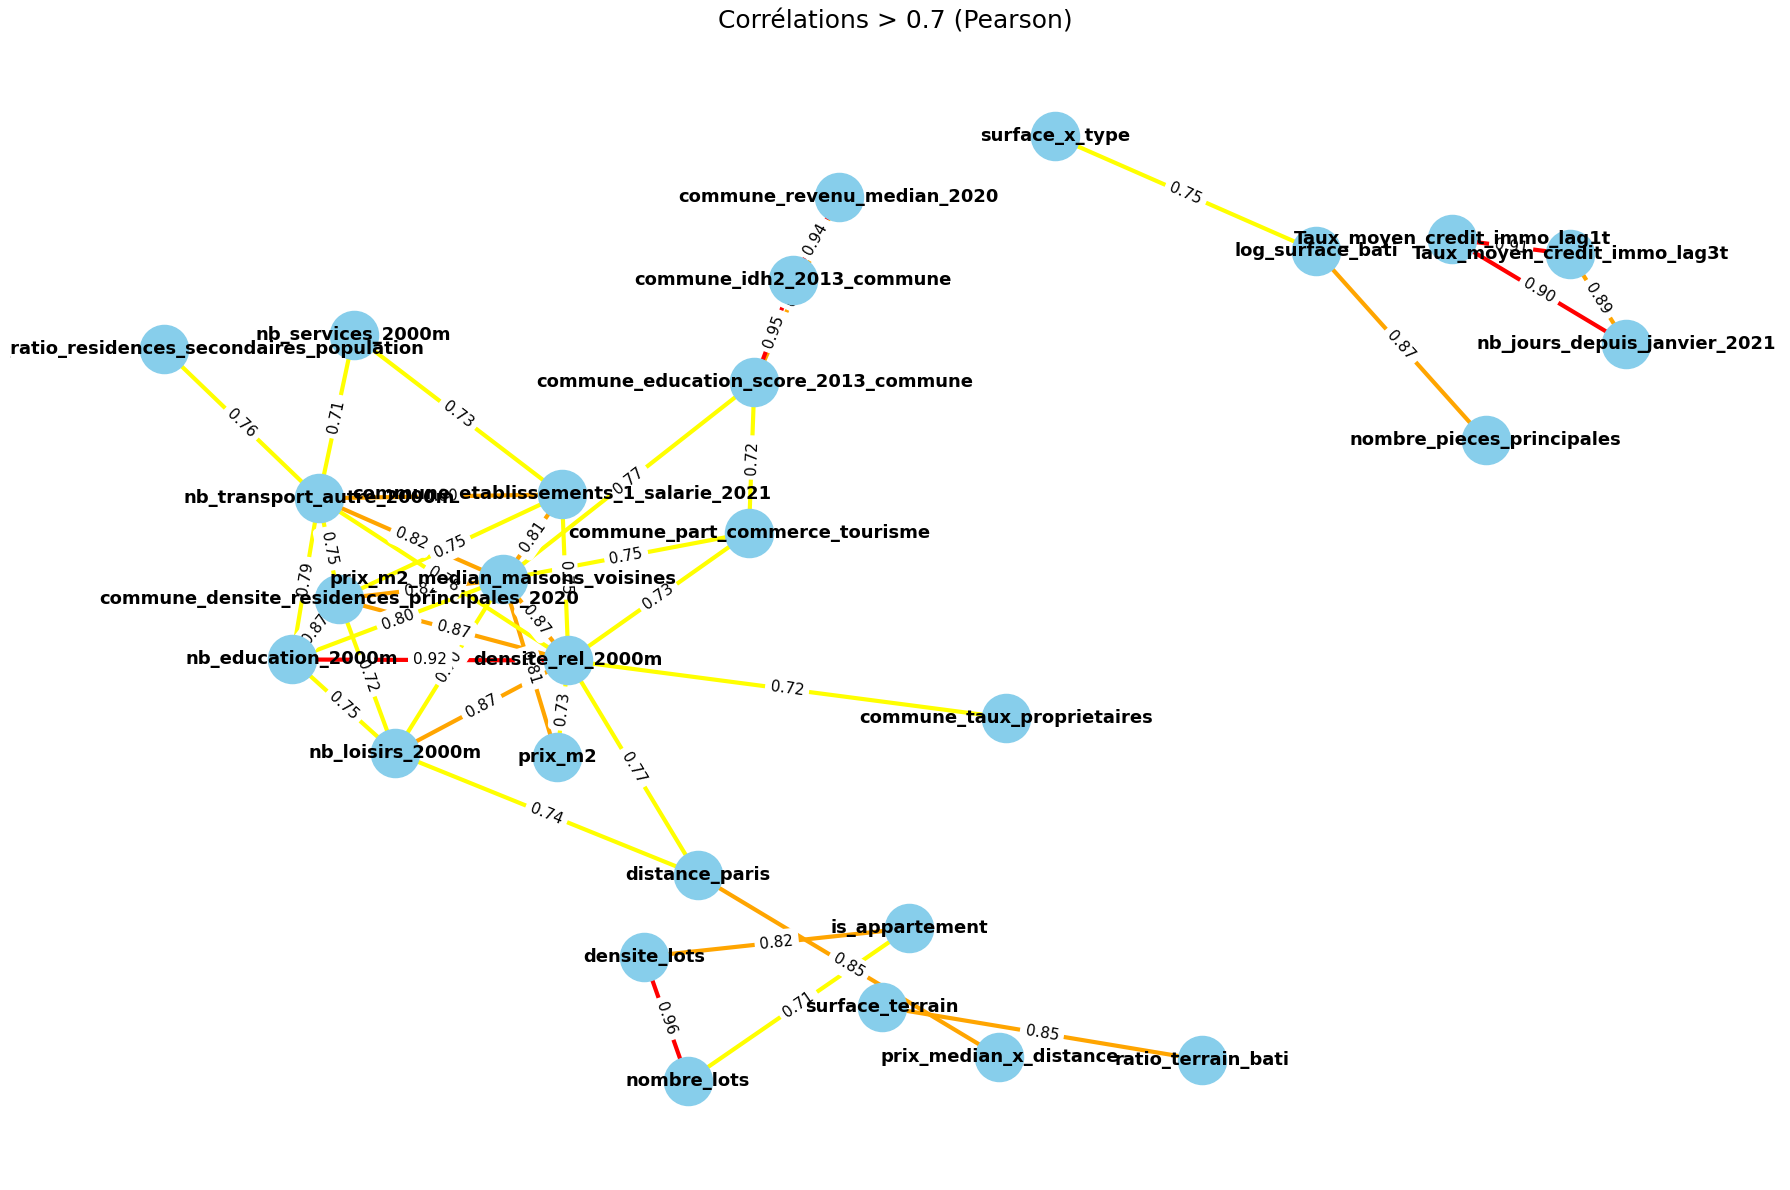

In [ ]:
def plot_strong_correlations(df, threshold=0.7, figsize=(18, 12), seed=42):
    corr_matrix = df.corr(method='pearson').abs()
    strong_corr = (corr_matrix > threshold) & (corr_matrix < 1.0)
    edges = [(i, j, corr_matrix.loc[i, j]) 
             for i in corr_matrix.columns 
             for j in corr_matrix.columns 
             if strong_corr.loc[i, j]]

    G = nx.Graph()
    for i, j, w in edges:
        G.add_edge(i, j, weight=w)

    edge_colors = []
    for u, v in G.edges():
        w = G[u][v]['weight']
        if threshold < w <= 0.8:
            edge_colors.append('yellow')
        elif 0.8 < w <= 0.9:
            edge_colors.append('orange')
        elif w > 0.9:
            edge_colors.append('red')
        else:
            edge_colors.append('grey')

    plt.figure(figsize=figsize)
    pos = nx.spring_layout(G, k=0.6, seed=seed)
    nx.draw_networkx_nodes(G, pos, node_size=1200, node_color="#87CEEB")
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=3)
    nx.draw_networkx_labels(G, pos, font_size=13, font_weight='bold')
    edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='black', font_size=11)
    plt.title(f"Corrélations > {threshold} (Pearson)", fontsize=18)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_strong_correlations(df_train_with_selected_features, threshold=0.7)

A partir de cette annalyse on va enlever quelques variables, on garde à chaque fois la variable qui a la plus grande valeur de shapley:

In [24]:
correlated_features_to_drop = ["surface_terrain",
                               "densite_lots", 
                               "nombre_pieces_principales",
                               "Taux_moyen_credit_immo_lag3t", 
                               "nb_jours_depuis_janvier_2021", # cette variable ne fait pas sens
                               "nb_education_2000m", 
                               "commune_idh2_2013_commune", 
                               "prix_median_x_distance"
                               ]

df_train_with_selected_features = df_train_with_selected_features.drop(columns=correlated_features_to_drop, errors='ignore')
df_train_with_selected_features

,prix_m2_median_maisons_voisines,ratio_terrain_bati,commune_education_score_2013_commune,densite_rel_2000m,surface_x_type,nombre_lots,nb_transport_autre_2000m,commune_part_commerce_tourisme,log_surface_bati,is_appartement,...,commune_etablissements_1_salarie_2021,commune_ratio_residences_secondaires_population,surface_par_piece,dist_transport_lourd,Taux_moyen_credit_immo_lag1t,commune_taux_proprietaires,Evolution_PIB_volume_en_%_base2020_lag4t,nb_services_2000m,nb_loisirs_2000m,prix_m2
0,9782.608398,0.000000,0.902589,1.355828,160,1,27,0.848215,4.394449,1,...,9368,0.095065,26.666666,268.899414,0.0373,0.325563,0.193834,17,290,7750.000000
1,5606.589355,0.000000,0.451268,0.241548,52,1,4,0.643595,3.295837,1,...,1738,0.013689,13.000000,319.581665,0.0399,0.282208,0.900489,8,235,4500.000000
2,3152.272705,0.000000,0.636588,-1.289530,101,1,2,0.600000,4.624973,0,...,56,0.014819,20.200001,1018.376892,0.0329,0.811383,0.506923,2,33,2623.762451
3,10938.690430,0.000000,0.824937,2.088961,36,1,31,0.852084,2.944439,1,...,6757,0.093602,18.000000,272.015564,0.0106,0.370956,15.361810,17,307,12111.111328
4,5555.555664,1.843374,0.650801,0.010234,83,0,1,0.773960,4.430817,0,...,430,0.016016,16.600000,992.912659,0.0106,0.483656,15.361810,3,228,8192.771484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507383,3135.065430,0.000000,0.549603,0.113545,204,2,0,0.724356,4.634729,1,...,1638,0.005919,20.400000,519.641785,0.0284,0.344608,0.440900,10,248,2774.509766
507384,7936.507812,0.000000,0.702535,0.693273,92,2,4,0.761356,3.850147,1,...,2124,0.026443,23.000000,366.157837,0.0113,0.422412,-12.214629,14,226,7282.608887
507385,1771.571777,0.000000,0.234840,-0.880271,76,1,1,0.664062,4.343805,0,...,539,0.004408,19.000000,1181.921875,0.0113,0.423093,-12.214629,3,33,2763.157959
507386,5403.879395,0.000000,0.470862,1.436748,160,1,4,0.739228,4.394449,1,...,1926,0.014755,26.666666,279.064087,0.0105,0.283137,-0.105712,15,331,5000.000000


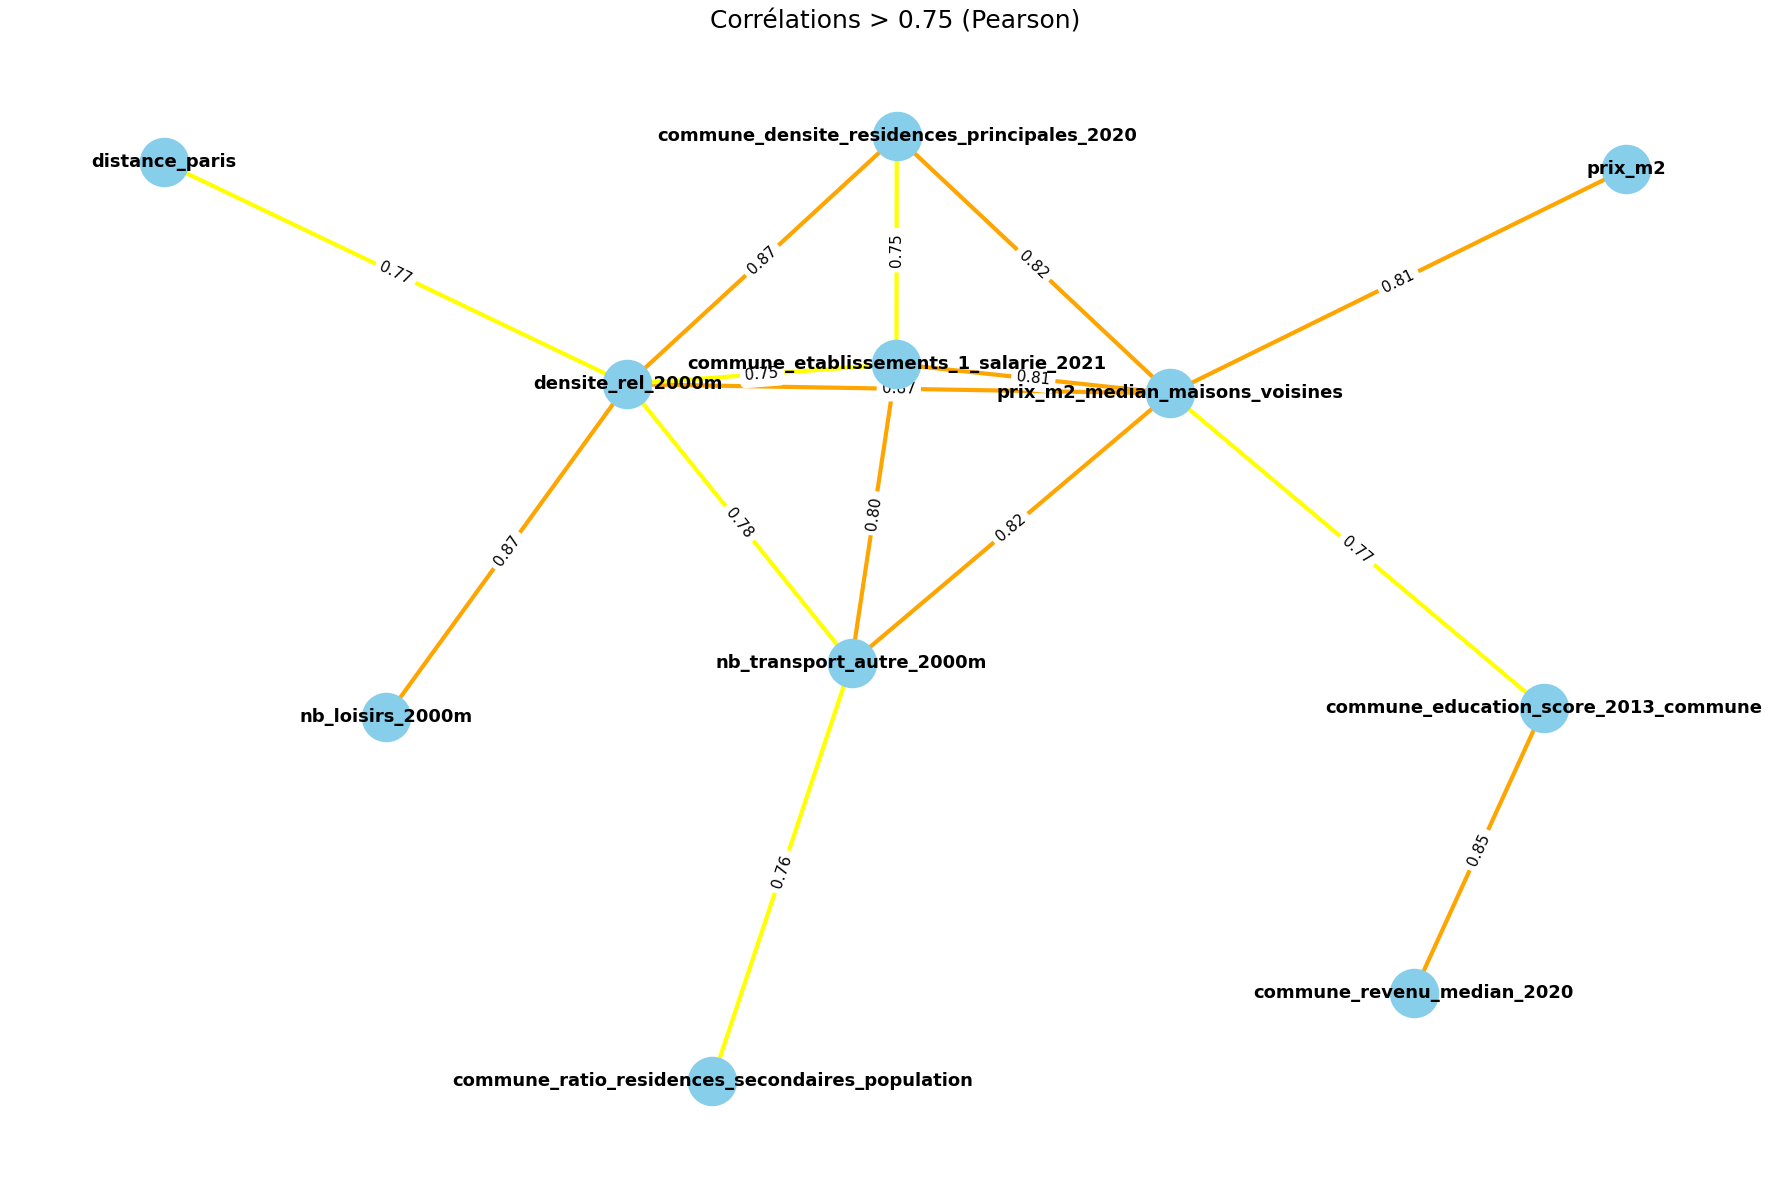

In [25]:
plot_strong_correlations(df_train_with_selected_features, threshold=0.75)

Pour des modèles d'arbre ce n'est pas très grave pour la performance du modèle d'avoir des corrélations. Donc pour l'instant on garde le dataframe tel quel. Pour mieux comprendre les drivers du prix au mètre carré il faudra enlever le prix médian du metre carré des maisons voisines. 

Appliquer la selection à l'échantillon test et OOT :

In [26]:
test_df = pd.read_parquet(r"data/processed/train_test_out_sample_cleaned/idf_vf_test_cleaned.parquet")
test_df = test_df[selected_features + ["prix_m2"]]
test_df = test_df.drop(columns=correlated_features_to_drop, errors='ignore')
test_df

,prix_m2_median_maisons_voisines,ratio_terrain_bati,commune_education_score_2013_commune,densite_rel_2000m,surface_x_type,nombre_lots,nb_transport_autre_2000m,commune_part_commerce_tourisme,log_surface_bati,is_appartement,...,commune_etablissements_1_salarie_2021,commune_ratio_residences_secondaires_population,surface_par_piece,dist_transport_lourd,Taux_moyen_credit_immo_lag1t,commune_taux_proprietaires,Evolution_PIB_volume_en_%_base2020_lag4t,nb_services_2000m,nb_loisirs_2000m,prix_m2
0,7319.250977,0.000000,0.786667,1.363134,46,1,5,0.823801,3.178054,1,...,1203,0.037000,23.000000,775.308411,0.0359,0.398941,0.451942,8,441,7147.826172
1,7331.214844,0.000000,0.832653,1.300839,210,1,4,0.837838,4.663439,1,...,2249,0.081091,26.250000,256.409119,0.0140,0.428526,2.991206,15,356,7980.952148
2,11411.458008,0.000000,0.937021,1.558150,302,2,46,0.904373,5.023880,1,...,16207,0.257066,37.750000,210.827072,0.0420,0.388839,0.075596,62,180,12317.880859
3,4528.928711,14.385965,0.586714,-0.635809,57,0,0,0.483516,4.060443,0,...,59,0.006706,19.000000,2193.941650,0.0178,0.654517,0.559991,3,77,8719.297852
4,2990.362305,0.000000,0.649757,-0.999867,119,1,2,0.674528,4.787492,0,...,166,0.007979,29.750000,108.422150,0.0105,0.682505,0.399707,1,54,2815.125977
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126843,3795.454590,1.735294,0.685132,-0.590734,34,0,1,0.701299,3.555348,0,...,286,0.008432,17.000000,658.067627,0.0105,0.649225,0.399707,5,161,4289.706055
126844,10100.000000,0.000000,0.865192,0.427209,44,1,6,0.804709,3.135494,1,...,1681,0.036750,22.000000,29.374443,0.0178,0.478174,0.559991,7,291,10000.000000
126845,3167.094727,0.000000,0.469415,-1.289505,94,1,1,0.683168,4.553877,0,...,75,0.109685,18.799999,533.554138,0.0140,0.697908,2.991206,4,47,2340.425537
126846,5956.410156,0.000000,0.410136,0.903930,80,1,5,0.703074,3.713572,1,...,841,0.007103,20.000000,405.890564,0.0113,0.322951,-12.214629,10,275,4950.000000


In [27]:
oos_df = pd.read_parquet(r"data/processed/train_test_out_sample_cleaned/idf_vf_out_of_sample_cleaned.parquet")
oos_df = oos_df[selected_features + ["prix_m2"]]
oos_df = oos_df.drop(columns=correlated_features_to_drop, errors='ignore')
oos_df

,prix_m2_median_maisons_voisines,ratio_terrain_bati,commune_education_score_2013_commune,densite_rel_2000m,surface_x_type,nombre_lots,nb_transport_autre_2000m,commune_part_commerce_tourisme,log_surface_bati,is_appartement,...,commune_etablissements_1_salarie_2021,commune_ratio_residences_secondaires_population,surface_par_piece,dist_transport_lourd,Taux_moyen_credit_immo_lag1t,commune_taux_proprietaires,Evolution_PIB_volume_en_%_base2020_lag4t,nb_services_2000m,nb_loisirs_2000m,prix_m2
0,4005.208252,0.000000,0.400966,0.003226,144,1,2,0.635346,4.290460,1,...,1430,0.010006,24.000000,134.432617,0.0338,0.372387,0.144057,8,255,3097.222168
1,3682.135010,0.000000,0.610739,-0.832668,156,2,0,0.823000,4.369448,1,...,584,0.036247,19.500000,135.523117,0.0338,0.409828,0.144057,7,72,3551.281982
2,5482.353027,0.000000,0.889821,-0.042039,30,1,0,0.810565,2.772589,1,...,418,0.026782,15.000000,145.372406,0.0338,0.477340,0.144057,2,174,8000.000000
3,8277.418945,0.000000,0.835437,0.742554,124,1,5,0.834500,4.143135,1,...,1613,0.054721,20.666666,622.195190,0.0338,0.422396,0.144057,6,314,7658.467773
4,2683.333252,0.000000,0.389963,-0.651608,204,1,1,0.659074,4.634729,1,...,937,0.004541,20.400000,1174.676025,0.0338,0.391079,0.144057,8,127,1980.392212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47763,3621.912109,3.026316,0.523603,-1.089169,76,0,0,0.633484,4.343805,0,...,307,0.005232,19.000000,2226.469971,0.0316,0.649097,0.191300,2,94,3723.684326
47764,3579.545410,0.000000,0.473365,-0.129552,184,1,0,0.619617,4.532599,1,...,330,0.009441,23.000000,1345.507935,0.0316,0.650443,0.191300,6,213,1569.934814
47765,4420.212891,0.000000,0.682606,0.208427,120,1,2,0.755556,4.110874,1,...,103,0.044261,20.000000,1653.855713,0.0316,0.453915,0.191300,3,326,5000.000000
47766,4289.473633,3.674797,0.639937,-1.055975,123,0,1,0.637681,4.820282,0,...,104,0.004543,20.500000,1396.173706,0.0316,0.730947,0.191300,2,64,3869.918701


Export de la base :

In [28]:
df_train_with_selected_features.to_parquet(r"data/processed/selected_features/idf_vf_train_test_selected_features.parquet", index=False)
test_df.to_parquet(r"data/processed/selected_features/idf_vf_test_selected_features.parquet", index=False)
oos_df.to_parquet(r"data/processed/selected_features/idf_vf_out_of_sample_selected_features.parquet", index=False)